---
## 📡 GNSS-DEMO

Welcome to your hands-on guide for processing GNSS data with SAGE/GAGE! In this notebook, we’ll take you on a two-track journey:

1. #### **🚶 Traditional Serial Processing**  

   – Download RINEX files one by one to your local GeoLab environment  
   – Run the standard GNSS processing pipeline step-by-step  
   – See how long each stage takes and where the bottlenecks lie  

2. #### **☁️ Cloud-Optimized Workflow**  

   – Stream data directly from an AWS S3 bucket—no massive local downloads  
   – Parallelize your work with Dask-Gateway for lightning-fast throughput  
   – Compare performance metrics against the serial approach  

Don’t worry if “S3” and “Dask” are unfamiliar terms right now—we’ll introduce each concept with clear, jargon-free explanations right when you need them.

---

## 1️⃣ Traditional Serial Processing
In this section, we’ll explore the classic method of GNSS data handling which is downloading RINEX files to your GeoLab environment and processing them one by one.  
RINEX (Receiver Independent Exchange Format) is the open, ASCII-based standard for recording raw GNSS observations—packaging pseudorange, carrier-phase, navigation, and meteorological data into a human-readable, vendor-neutral text format.

More about 👉 [RINEX](https://igs.org/wg/rinex/)

**What you’ll do here:**  
1. **Set up storage:** Create a `./rinex_data` directory for your downloads.  
2. **Batch download:** Loop over days 1–9 of 2024 and fetch each RINEX file from the EarthScope archive on S3.  
3. **Parse with GeoRINEX:** Load the GPS L1C signal‐to‐noise ratio (`S1`) into an xarray dataset.  
4. **Compute daily mean SNR:** Calculate the average SNR for each file and record its date.  
5. **Clean up:** Delete each file after processing to keep your workspace tidy.  
6. **Time it all:** Use `time.time()` to capture the total download + processing runtime.  
7. **Visualize results:** Plot daily mean SNR vs. date, overlay the overall average, and annotate the total elapsed time in the title.  

First, we’ll install the GeoRINEX package into a temporary environment using a bash script. 

For more details, 👉 [GeoRINEX GitHub repository](https://github.com/geospace-code/georinex/tree/main) 👉 [Bash scripting inside notebook](https://stackoverflow.com/questions/58981651/how-to-run-a-shell-script-in-jupyter-notebook)

In [ ]:
!pip install georinex

Now, we need to build a function for authentication. This function kicks off a one-time, browser-based sign-in and then quietly refreshes your credentials so you don’t have to log in again. When you give it the web address of the data file and a folder on your computer, it securely fetches and saves the file for you. If the download fails—say the URL is wrong or your login has lapsed—it prints a straightforward error message so you know what to fix.

To learn more about how it works, 👉 [earthscope-sdk](https://pypi.org/project/earthscope-sdk/)

In [7]:
# ____ Authentication function __________________________________________________
import requests
from pathlib import Path
from earthscope_sdk.auth.device_code_flow import DeviceCodeFlowSimple
from earthscope_sdk.auth.auth_flow import NoTokensError

def get_es_file(url, directory_to_save_file='./', token_path='./'):
    """function to get earthscope data using es-sdk
    modified from https://gitlab.com/earthscope/public/earthscope-sdk

    Parameters
    ----------
    url : string
        url of desired file at gage-data.earthscope.org
    directory_to_save_file : str, optional
        path of directory in which to save the file, by default cwd
    token_path : str, optional
        path of directory in which to save the token, by default './'
    """
    # instantiate the device code flow subclass
    device_flow = DeviceCodeFlowSimple(Path(token_path))
    try:
      # get access token from local path
      device_flow.get_access_token_refresh_if_necessary()
    except NoTokensError:
      # if no token was found locally, do the device code flow
      device_flow.do_flow()
    token = device_flow.access_token

    # request a file and provide the token in the Authorization header
    file_name = Path(url).name

    r = requests.get(url, headers={"authorization": f"Bearer {token}"})
    if r.status_code == requests.codes.ok:
      # save the file
      with open(Path(Path(directory_to_save_file) / file_name), 'wb') as f:
          for data in r:
              f.write(data)
    else:
      #problem occured
      print(f"failure: {r.status_code}, {r.reason}")

Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/001/p0570010.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/002/p0570020.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/003/p0570030.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/004/p0570040.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/005/p0570050.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/006/p0570060.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/007/p0570070.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/008/p0570080.24d.Z
Downloading: https://gage-data.earthscope.org/archive/gnss/rinex/obs/2024/009/p0570090.24d.Z
Processed 9 days in 25.9 seconds.
Overall mean L1C SNR: 43.23


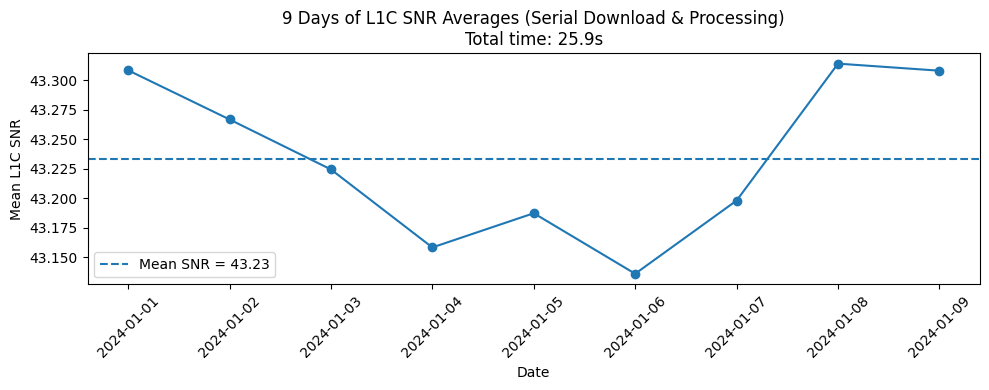

In [8]:
# ── Imports & Setup ─────────────────────────────────────────────────────────────

import os
import time
import numpy as np
import matplotlib.pyplot as plt
import georinex as gr                    # GeoRINEX: convert RINEX -> xarray datasets
from datetime import datetime, timedelta

# ── Configuration ──────────────────────────────────────────────────────────────

# Directory to store downloaded RINEX files
rinex_dir = "./rinex_data"
os.makedirs(rinex_dir, exist_ok=True)

# Lists to collect timing & SNR results
snr_list   = []    # daily mean signal-to-noise ratios
dates      = []    # corresponding dates
start_time = None  # will hold the timestamp when downloading starts

year = 2024        # the year of observation data

# ── Serial Download & Processing Loop ──────────────────────────────────────────

# Record the start time
start_time = time.time()

# Loop over day-of-year (DOY) 1 through 9
for doy in np.arange(1, 10):
    # 1️⃣ Build the URL for the RINEX file on the EarthScope S3 archive
    filename = f"p057{doy:03d}0.24d.Z"
    url      = f"https://gage-data.earthscope.org/archive/gnss/rinex/obs/{year}/{doy:03d}/{filename}"
    print(f"Downloading: {url}")

    # 2️⃣ Download the file into our rinex_dir
    get_es_file(url, rinex_dir)

    # 3️⃣ Load the downloaded RINEX file into an xarray dataset
    filepath = os.path.join(rinex_dir, filename)
    obs      = gr.load(filepath, use='G', meas=['S1'])  
    #    - use='G' restricts to GPS satellites
    #    - meas=['S1'] loads only the L1C signal-to-noise ratio

    # 4️⃣ Compute the daily average SNR across all epochs & satellites
    daily_mean_snr = obs['S1'].mean().values
    snr_list.append(daily_mean_snr)

    # 5️⃣ Record the corresponding calendar date
    date = datetime(year, 1, 1) + timedelta(days=int(doy - 1))
    dates.append(date)

    # 6️⃣ Clean up: delete the RINEX file to save disk space
    os.remove(filepath)

# Record end time and compute total elapsed time
end_time  = time.time()
total_time = end_time - start_time

# ── Summary Statistics ─────────────────────────────────────────────────────────

overall_mean_snr = np.mean(snr_list)
print(f"Processed {len(snr_list)} days in {total_time:.1f} seconds.")
print(f"Overall mean L1C SNR: {overall_mean_snr:.2f}")

# ── Visualization ──────────────────────────────────────────────────────────────

plt.figure(figsize=(10, 4))
plt.plot(dates, snr_list, marker='o', linestyle='-')
plt.axhline(overall_mean_snr, linestyle='--', label=f"Mean SNR = {overall_mean_snr:.2f}")
plt.title(f"{len(dates)} Days of L1C SNR Averages (Serial Download & Processing)\nTotal time: {total_time:.1f}s")
plt.xlabel("Date")
plt.ylabel("Mean L1C SNR")
plt.xticks(rotation=45)
plt.legend(loc='best')
plt.tight_layout()
plt.show()
